# Notebook para graficar espectros de reflectancia

Este notebook permite leer un archivo CSV desde la carpeta `results/model/reflectance_data` y graficar el espectro de reflectancia usando las columnas `wavelength_nm` y `reflectance`.

In [1]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Leer archivo CSV desde la carpeta results/model/reflectance_data
csv_path = '../results/reflectance_data/rhetenor/rhetenor_regular_aligned_total_270.csv'
df = pd.read_csv(csv_path)

In [5]:
# Visualizar las primeras filas del archivo
df.head()

,wavelength_nm,reflectance
0,800.000000,0.092253
1,791.167192,0.124169
2,782.527301,0.151810
3,774.074074,0.167203
4,765.801527,0.175716


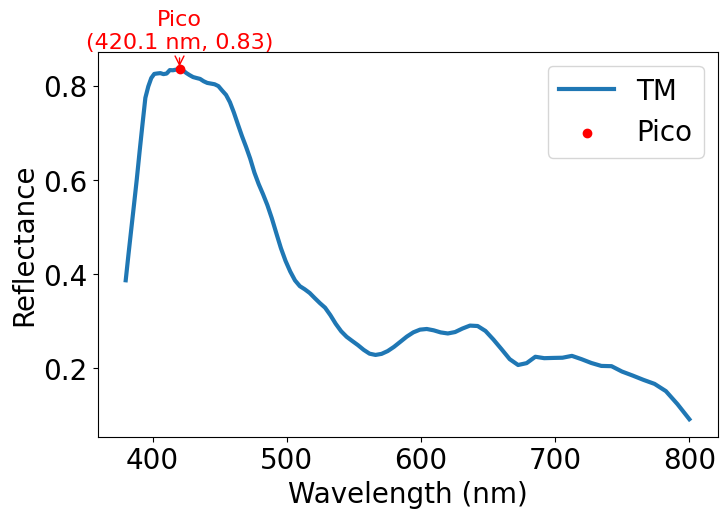

In [6]:
# Graficar espectro de reflectancia
plt.figure(figsize=(8,5))
plt.plot(df['wavelength_nm'], df['reflectance'], label='TM', linewidth=3)
plt.xlabel('Wavelength (nm)', fontsize=20)
plt.ylabel('Reflectance', fontsize=20)
# Encontrar el pico del espectro
idx_max = df['reflectance'].idxmax()
peak_wavelength = df.loc[idx_max, 'wavelength_nm']
peak_reflectance = df.loc[idx_max, 'reflectance']
plt.scatter(peak_wavelength, peak_reflectance, color='red', zorder=5, label='Pico')
plt.annotate(f'Pico\n({peak_wavelength:.1f} nm, {peak_reflectance:.2f})',
             (peak_wavelength, peak_reflectance),
             textcoords='offset points', xytext=(0,15), ha='center', fontsize=16, color='red', arrowprops=dict(arrowstyle='->', color='red'))
plt.legend(fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.show()

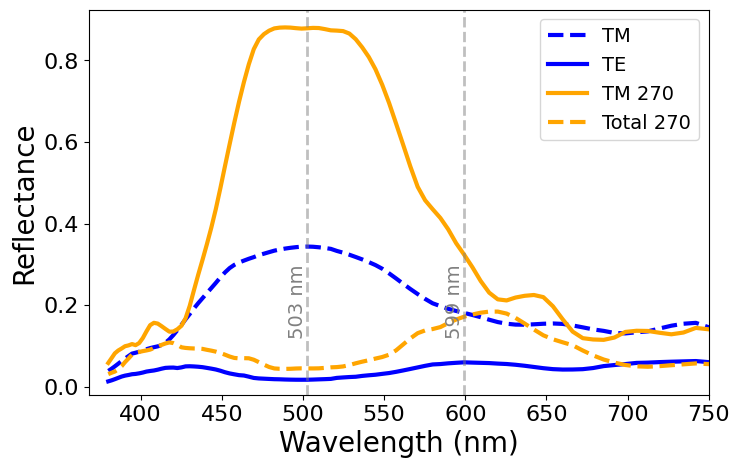

In [63]:
# Graficar dos espectros en el mismo plot en su escala real (sin normalizar)
csv_path_4 = '../results/reflectance_data/menelaus_G_cross.csv'
csv_path_3 = '../results/reflectance_data/menelaus_G_parallel.csv'

csv_path_2 = '../results/reflectance_data/menelaus_C_cross.csv'
csv_path_1 = '../results/reflectance_data/menelaus_C_parallel.csv'
# Leer ambos archivos
spec1 = pd.read_csv(csv_path_1)
spec2 = pd.read_csv(csv_path_2)

spec3 = pd.read_csv(csv_path_3)
spec4 = pd.read_csv(csv_path_4)
# Filtrar rango 350-700 nm
spec1_filt = spec1[(spec1['wavelength_nm'] >= 350) & (spec1['wavelength_nm'] <= 700)]
spec2_filt = spec2[(spec2['wavelength_nm'] >= 350) & (spec2['wavelength_nm'] <= 700)]
spec3_filt = spec3[(spec3['wavelength_nm'] >= 350) & (spec3['wavelength_nm'] <= 700)]
spec4_filt = spec4[(spec4['wavelength_nm'] >= 350) & (spec4['wavelength_nm'] <= 700)]
# Identificar el índice y valores de los picos (en los datos originales)
idx1 = spec1_filt['reflectance'].idxmax()
idx2 = spec2_filt['reflectance'].idxmax()
peak1_wl = spec1.loc[idx1, 'wavelength_nm']
peak1_val = spec1.loc[idx1, 'reflectance']
peak2_wl = spec2.loc[idx2, 'wavelength_nm']
peak2_val = spec2.loc[idx2, 'reflectance']

label1 = 'TM'
label2 = 'TE'

# Graficar
plt.figure(figsize=(8,5))
plt.plot(spec1['wavelength_nm'], spec1['reflectance'], label=label1, color='blue', linewidth=3, linestyle='--')
plt.plot(spec2['wavelength_nm'], spec2['reflectance'], label=label2, color='blue', linewidth=3)
plt.plot(spec3['wavelength_nm'], spec3['reflectance'], label='TM 270', color='orange', linewidth=3)
plt.plot(spec4['wavelength_nm'], spec4['reflectance'], label='Total 270', color='orange', linewidth=3, linestyle='--')

# Línea gris punteada para cada pico con opacidad
plt.axvline(x=peak1_wl, color=(0.5,0.5,0.5,0.5), linestyle='--', linewidth=2)
plt.axvline(x=peak2_wl, color=(0.5,0.5,0.5,0.5), linestyle='--', linewidth=2)

# Texto gris debajo del eje x pero más arriba (por ejemplo, en y=0.2) mostrando la longitud de onda
plt.text(peak1_wl, 0.3, f'{peak1_wl:.0f} nm', color='gray', fontsize=14, ha='right', va='top', rotation=90)
plt.text(peak2_wl, 0.3, f'{peak2_wl:.0f} nm', color='gray', fontsize=14, ha='right', va='top', rotation=90)

plt.xlabel('Wavelength (nm)', fontsize=20)
plt.ylabel('Reflectance', fontsize=20)
plt.legend(fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.xlim(368, 750)
plt.ylim(bottom=-0.02)
plt.show()

NameError: name 'peak1_wl' is not defined

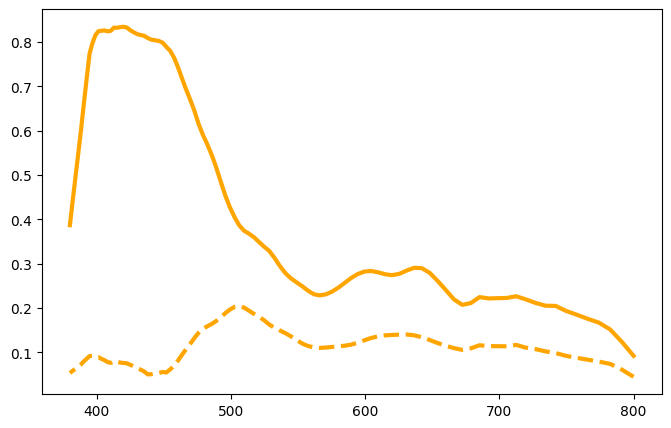

In [10]:
# Graficar dos espectros en el mismo plot en su escala real (sin normalizar)
csv_path_4 = '../results/reflectance_data/rhetenor/rhetenor_regular_aligned_cross_270.csv'
csv_path_3 = '../results/reflectance_data/rhetenor/rhetenor_regular_aligned_total_270.csv'

#csv_path_2 = '../results/reflectance_data/menelaus_C_cross.csv'
#csv_path_1 = '../results/reflectance_data/menelaus_C_parallel.csv'
# Leer ambos archivos
#spec1 = pd.read_csv(csv_path_1)
#spec2 = pd.read_csv(csv_path_2)

spec3 = pd.read_csv(csv_path_3)
spec4 = pd.read_csv(csv_path_4)
# Filtrar rango 350-700 nm
#spec1_filt = spec1[(spec1['wavelength_nm'] >= 350) & (spec1['wavelength_nm'] <= 700)]
#spec2_filt = spec2[(spec2['wavelength_nm'] >= 350) & (spec2['wavelength_nm'] <= 700)]
spec3_filt = spec3[(spec3['wavelength_nm'] >= 350) & (spec3['wavelength_nm'] <= 700)]
spec4_filt = spec4[(spec4['wavelength_nm'] >= 350) & (spec4['wavelength_nm'] <= 700)]
# Identificar el índice y valores de los picos (en los datos originales)
#idx1 = spec1_filt['reflectance'].idxmax()
#idx2 = spec2_filt['reflectance'].idxmax()
#peak1_wl = spec1.loc[idx1, 'wavelength_nm']
#peak1_val = spec1.loc[idx1, 'reflectance']
#peak2_wl = spec2.loc[idx2, 'wavelength_nm']
#peak2_val = spec2.loc[idx2, 'reflectance']

label1 = 'TM'
label2 = 'TE'

# Graficar
plt.figure(figsize=(8,5))
#plt.plot(spec1['wavelength_nm'], spec1['reflectance'], label=label1, color='blue', linewidth=3, linestyle='--')
#plt.plot(spec2['wavelength_nm'], spec2['reflectance'], label=label2, color='blue', linewidth=3)
plt.plot(spec3['wavelength_nm'], spec3['reflectance'], label='TM 270', color='orange', linewidth=3)
plt.plot(spec4['wavelength_nm'], spec4['reflectance'], label='Total 270', color='orange', linewidth=3, linestyle='--')

# Línea gris punteada para cada pico con opacidad
plt.axvline(x=peak1_wl, color=(0.5,0.5,0.5,0.5), linestyle='--', linewidth=2)
plt.axvline(x=peak2_wl, color=(0.5,0.5,0.5,0.5), linestyle='--', linewidth=2)

# Texto gris debajo del eje x pero más arriba (por ejemplo, en y=0.2) mostrando la longitud de onda
plt.text(peak1_wl, 0.3, f'{peak1_wl:.0f} nm', color='gray', fontsize=14, ha='right', va='top', rotation=90)
plt.text(peak2_wl, 0.3, f'{peak2_wl:.0f} nm', color='gray', fontsize=14, ha='right', va='top', rotation=90)

plt.xlabel('Wavelength (nm)', fontsize=20)
plt.ylabel('Reflectance', fontsize=20)
plt.legend(fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.xlim(368, 750)
plt.ylim(bottom=-0.02)
plt.show()

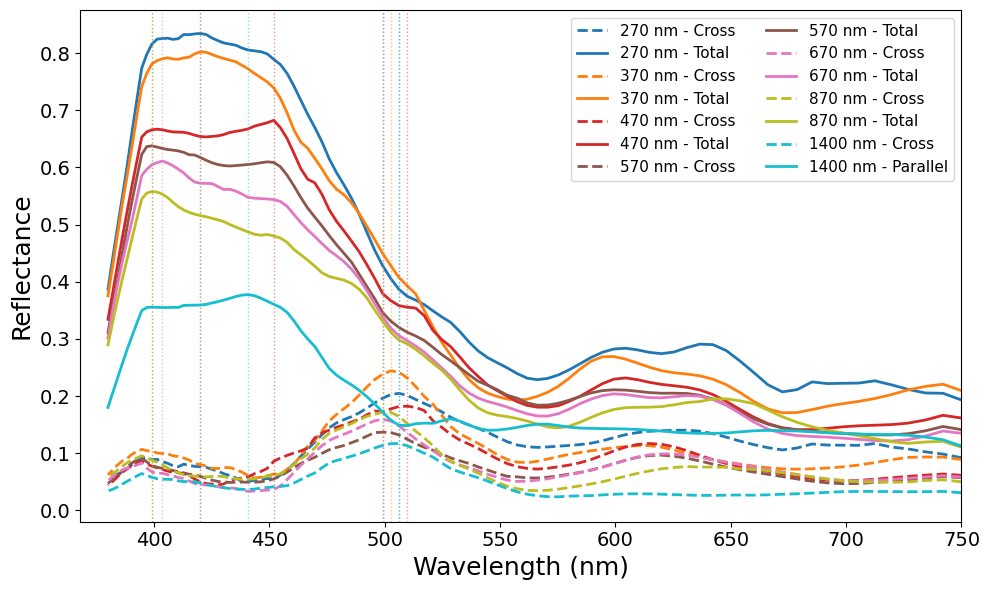

In [11]:

import os
import matplotlib.cm as cm
import numpy as np

def plot_rhetenor_spacings(base_path, spacings, wl_min=350, wl_max=750):
    """
    Plots cross and total/parallel reflectance spectra for each spacing value.
    Each spacing gets a unique color; cross = dashed, total/parallel = solid.
    """
    colors = cm.tab10(np.linspace(0, 1, len(spacings)))

    fig, ax = plt.subplots(figsize=(10, 6))

    for color, s in zip(colors, spacings):
        # Build file paths (handle 'total' vs 'parallel' naming)
        path_cross = os.path.join(base_path, f'rhetenor_regular_aligned_cross_{s}.csv')
        path_total = os.path.join(base_path, f'rhetenor_regular_aligned_total_{s}.csv')
        path_parallel = os.path.join(base_path, f'rhetenor_regular_aligned_parallel_{s}.csv')

        # Load cross
        if os.path.exists(path_cross):
            df_cross = pd.read_csv(path_cross)
            ax.plot(df_cross['wavelength_nm'], df_cross['reflectance'],
                    label=f'{s} nm - Cross', color=color, linewidth=2, linestyle='--')
            # Mark peak
            filt = df_cross[(df_cross['wavelength_nm'] >= wl_min) & (df_cross['wavelength_nm'] <= wl_max)]
            idx = filt['reflectance'].idxmax()
            peak_wl = df_cross.loc[idx, 'wavelength_nm']
            peak_val = df_cross.loc[idx, 'reflectance']
            ax.axvline(x=peak_wl, color=color, linestyle=':', linewidth=1, alpha=0.5)

        # Load total or parallel
        if os.path.exists(path_total):
            df_par = pd.read_csv(path_total)
            label_par = f'{s} nm - Total'
        elif os.path.exists(path_parallel):
            df_par = pd.read_csv(path_parallel)
            label_par = f'{s} nm - Parallel'
        else:
            df_par = None

        if df_par is not None:
            ax.plot(df_par['wavelength_nm'], df_par['reflectance'],
                    label=label_par, color=color, linewidth=2, linestyle='-')
            # Mark peak
            filt = df_par[(df_par['wavelength_nm'] >= wl_min) & (df_par['wavelength_nm'] <= wl_max)]
            idx = filt['reflectance'].idxmax()
            peak_wl = df_par.loc[idx, 'wavelength_nm']
            ax.axvline(x=peak_wl, color=color, linestyle=':', linewidth=1, alpha=0.5)

    ax.set_xlabel('Wavelength (nm)', fontsize=18)
    ax.set_ylabel('Reflectance', fontsize=18)
    ax.legend(fontsize=11, ncol=2, loc='upper right')
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlim(368, wl_max)
    ax.set_ylim(bottom=-0.02)
    plt.tight_layout()
    plt.show()


base_path = '../results/reflectance_data/rhetenor'
spacings = [270, 370, 470, 570, 670, 870, 1400]

plot_rhetenor_spacings(base_path, spacings)


In [ ]:

import os
import matplotlib.cm as cm
import numpy as np

def plot_menelaus_capas(base_path, capas_list, wl_min=350, wl_max=750):
    """
    Plots reflectance spectra for menelaus_Xcapas files.
    Each number of layers gets a unique color.
    """
    colors = cm.tab10(np.linspace(0, 1, len(capas_list)))

    fig, ax = plt.subplots(figsize=(10, 6))

    for color, n in zip(colors, capas_list):
        path = os.path.join(base_path, f'menelaus_{n}capas.csv')
        if not os.path.exists(path):
            print(f'No encontrado: {path}')
            continue

        df = pd.read_csv(path)
        ax.plot(df['wavelength_nm'], df['reflectance'],
                label=f'{n} capas', color=color, linewidth=2)

        # Mark peak
        filt = df[(df['wavelength_nm'] >= wl_min) & (df['wavelength_nm'] <= wl_max)]
        idx = filt['reflectance'].idxmax()
        peak_wl = df.loc[idx, 'wavelength_nm']
        ax.axvline(x=peak_wl, color=color, linestyle=':', linewidth=1, alpha=0.5)
        ax.text(peak_wl + 3, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0.05,
                f'{peak_wl:.0f} nm', color=color, fontsize=10, va='top', rotation=90)

    ax.set_xlabel('Wavelength (nm)', fontsize=18)
    ax.set_ylabel('Reflectance', fontsize=18)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlim(368, wl_max)
    ax.set_ylim(bottom=-0.02)
    plt.tight_layout()
    plt.show()


base_path = '../results/reflectance_data/menelaus'
capas = [3, 4, 5, 6, 7, 8, 9]

plot_menelaus_capas(base_path, capas)
